--- Phase 1: Minimizing Reconstruction MSE ---
Target: Heavy_Metals_Hg_ug_L   | Best MSE: 6.91e-26
Target: Heavy_Metals_Pb_ug_L   | Best MSE: 4.52e-23
Target: Heavy_Metals_Cd_ug_L   | Best MSE: 1.40e-24
Target: Ammonia_N_mg_L         | Best MSE: 7.00e-25
Target: Total_Phosphorus_mg_L  | Best MSE: 7.22e-26
Target: Nitrite_mg_L           | Best MSE: 2.33e-27


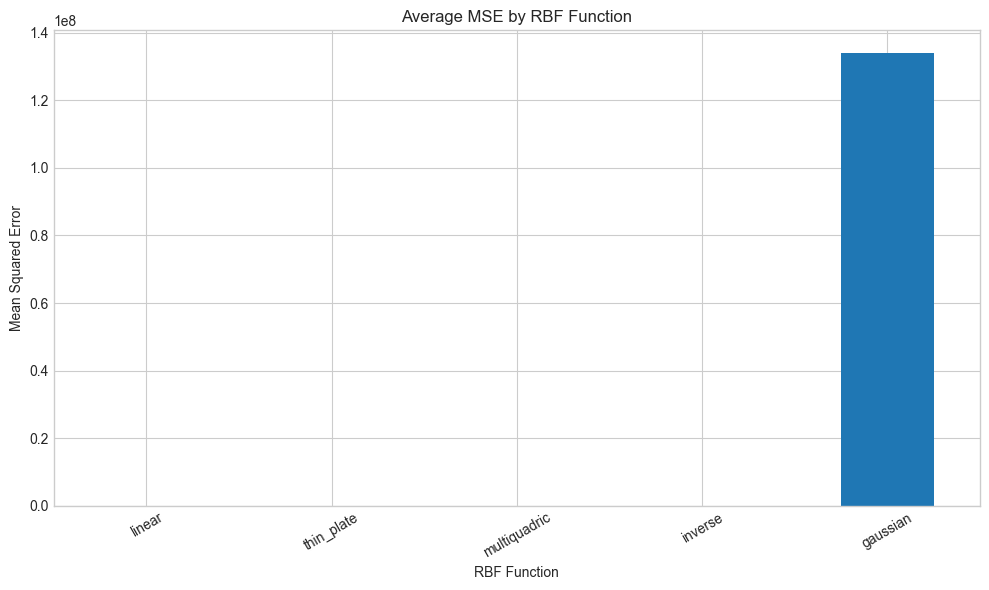

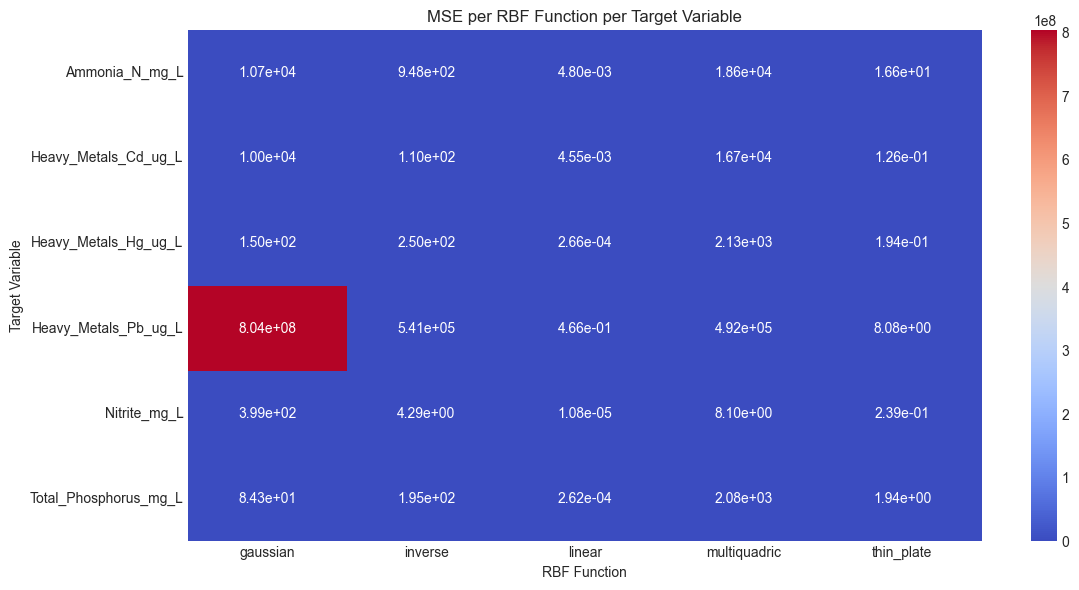


--- Phase 2: Final Reconstruction & MSE Validation ---


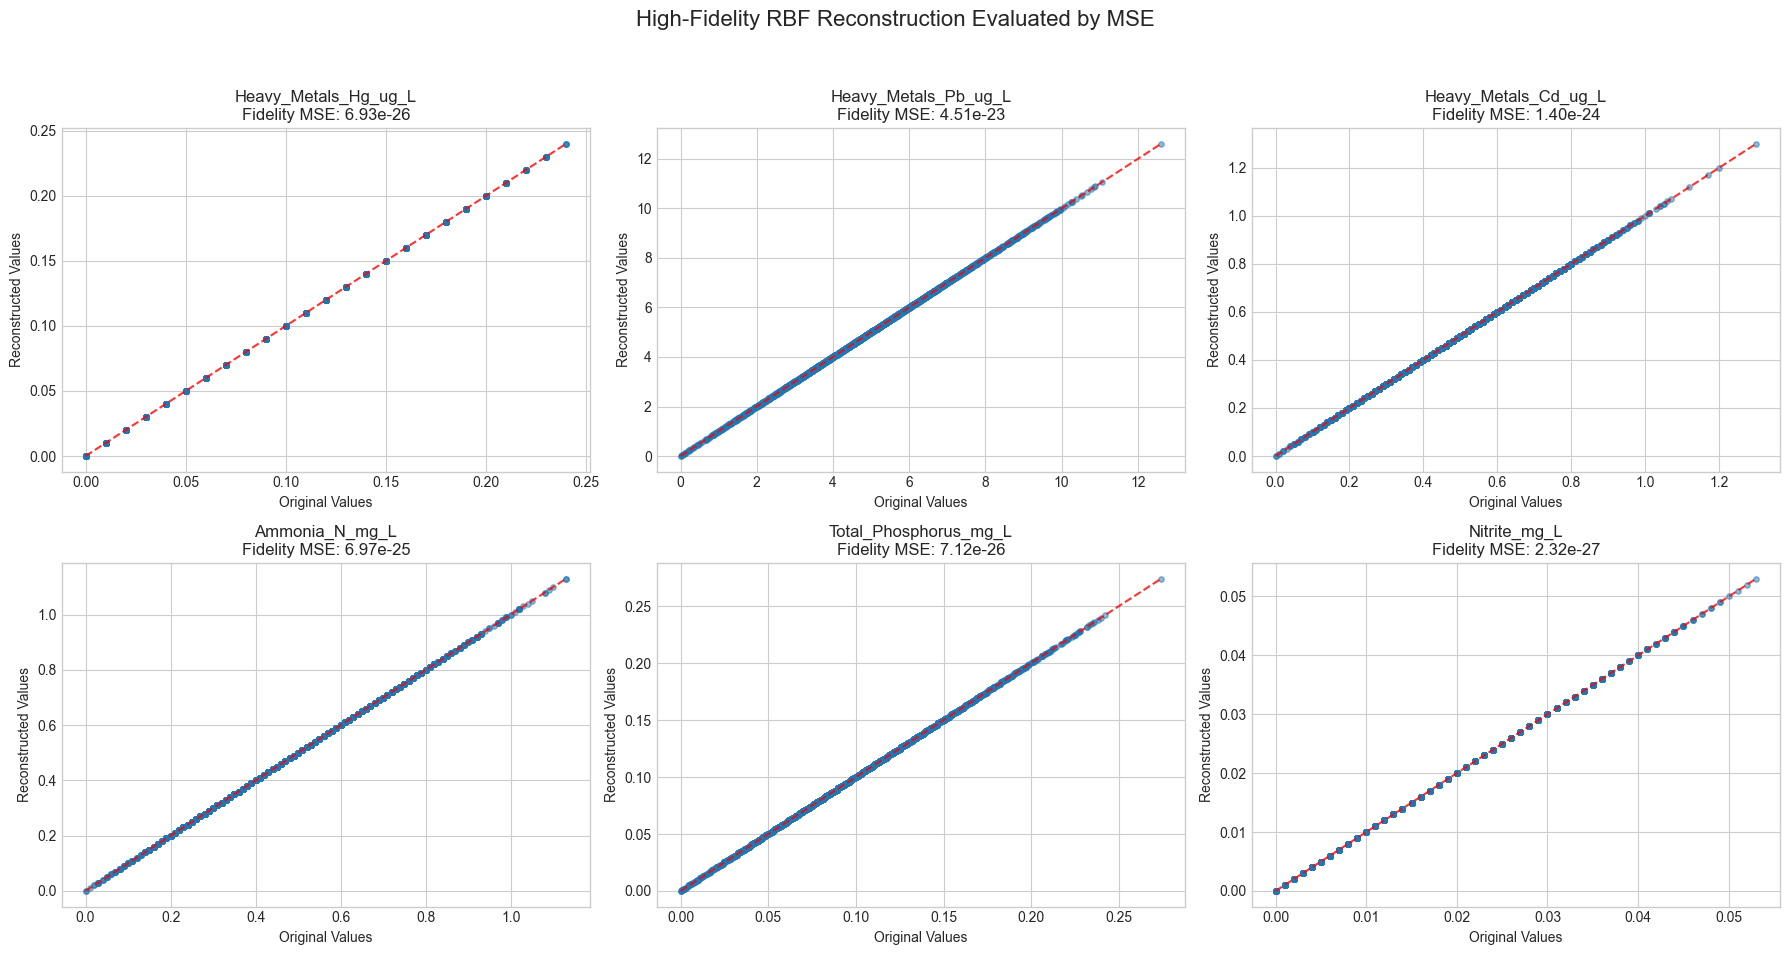


Process Complete. Dataset saved with optimized MSE.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 1. DATA LOADING & PREPARATION
try:
    df_raw = pd.read_csv('../data/china_water_pollution_data.csv')
    df_clean = df_raw.drop(columns=['Remarks'], errors='ignore')
    df_original = df_clean.copy()
    
    negative_value_cols = [
        'Heavy_Metals_Hg_ug_L', 'Heavy_Metals_Pb_ug_L', 'Heavy_Metals_Cd_ug_L',
        'Ammonia_N_mg_L', 'Total_Phosphorus_mg_L', 'Nitrite_mg_L'
    ]

    # Coordinate Scaling
    coords_scaler = MinMaxScaler()
    coords_raw = df_clean[['Longitude', 'Latitude']].values
    coords_scaled = coords_scaler.fit_transform(coords_raw)

    # 2. HYPER-PARAMETER OPTIMIZATION (Tracking MSE per RBF)
    param_grid = {
        'function': ['multiquadric', 'inverse', 'gaussian', 'linear', 'thin_plate'],
        'smooth': [0.0, 0.01],
        'epsilon': [0.1, 0.5, 1.0]
    }

    best_params_map = {}
    rbf_performance = {col: [] for col in negative_value_cols}

    print("--- Phase 1: Minimizing Reconstruction MSE ---")

    for col in negative_value_cols:
        y_orig = df_original[col].values
        mask = (y_orig >= 0) & (~np.isnan(y_orig))
        X_v, y_v = coords_scaled[mask], y_orig[mask]

        target_scaler = StandardScaler()
        y_scaled = target_scaler.fit_transform(y_v.reshape(-1, 1)).flatten()

        best_mse = float('inf')
        best_cfg = {}

        for params in ParameterGrid(param_grid):
            try:
                rbf_test = Rbf(X_v[:, 0], X_v[:, 1], y_scaled, **params)

                y_fit_scaled = rbf_test(X_v[:, 0], X_v[:, 1])
                y_fit = target_scaler.inverse_transform(y_fit_scaled.reshape(-1, 1)).flatten()

                current_mse = mean_squared_error(y_v, y_fit)

                rbf_performance[col].append({
                    'function': params['function'],
                    'smooth': params['smooth'],
                    'epsilon': params['epsilon'],
                    'mse': current_mse
                })

                if current_mse < best_mse:
                    best_mse = current_mse
                    best_cfg = params

            except:
                continue

        best_params_map[col] = best_cfg
        print(f"Target: {col:22} | Best MSE: {best_mse:.2e}")

    # 3. ANALYSIS OF RBF FUNCTION CHOICE
    perf_df = pd.concat(
        [pd.DataFrame(v).assign(target=k) for k, v in rbf_performance.items()],
        ignore_index=True
    )

    # Average MSE per function
    func_mse = perf_df.groupby('function')['mse'].mean().sort_values()

    plt.figure(figsize=(10, 6))
    func_mse.plot(kind='bar')
    plt.title('Average MSE by RBF Function')
    plt.xlabel('RBF Function')
    plt.ylabel('Mean Squared Error')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    # Heatmap per target
    pivot = perf_df.pivot_table(index='target', columns='function', values='mse', aggfunc='mean')

    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot, annot=True, fmt='.2e', cmap='coolwarm')
    plt.title('MSE per RBF Function per Target Variable')
    plt.xlabel('RBF Function')
    plt.ylabel('Target Variable')
    plt.tight_layout()
    plt.show()

    # 4. FINAL SYNTHESIS & PLOTTING
    print("\n--- Phase 2: Final Reconstruction & MSE Validation ---")

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, col in enumerate(negative_value_cols):
        y_raw = df_original[col].values
        v_mask = (y_raw >= 0) & (~np.isnan(y_raw))

        t_scaler = StandardScaler()
        y_train_full_scaled = t_scaler.fit_transform(y_raw[v_mask].reshape(-1, 1)).flatten()

        cfg = best_params_map[col]
        final_rbf = Rbf(coords_scaled[v_mask, 0], coords_scaled[v_mask, 1], y_train_full_scaled, **cfg)

        # Predict everything
        full_pred_scaled = final_rbf(coords_scaled[:, 0], coords_scaled[:, 1])
        full_pred = np.maximum(
            t_scaler.inverse_transform(full_pred_scaled.reshape(-1, 1)).flatten(),
            0
        )

        # Replace only invalid values
        df_clean[col] = np.where(v_mask, y_raw, full_pred)

        # Fidelity evaluation
        y_final_p = full_pred[v_mask]
        mse_val = mean_squared_error(y_raw[v_mask], y_final_p)

        ax = axes[idx]
        ax.scatter(y_raw[v_mask], y_final_p, alpha=0.5, s=15)
        limit = max(y_raw[v_mask].max(), y_final_p.max())
        ax.plot([0, limit], [0, limit], 'r--', alpha=0.8)
        ax.set_title(f"{col}\nFidelity MSE: {mse_val:.2e}")
        ax.set_xlabel('Original Values')
        ax.set_ylabel('Reconstructed Values')

    plt.suptitle('High-Fidelity RBF Reconstruction Evaluated by MSE', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Save result
    df_clean.to_csv('../output/mse_healed_data.csv', index=False)
    print("\nProcess Complete. Dataset saved with optimized MSE.")

except Exception as e:
    print(f"Pipeline Error: {e}")

--- Phase 1: Minimizing Reconstruction MSE ---
Target: Heavy_Metals_Hg_ug_L   | Best Function: linear | Smooth: 0.0 | Epsilon: 0.1 | MSE: 6.91e-26
Target: Heavy_Metals_Pb_ug_L   | Best Function: linear | Smooth: 0.0 | Epsilon: 0.1 | MSE: 4.52e-23
Target: Heavy_Metals_Cd_ug_L   | Best Function: linear | Smooth: 0.0 | Epsilon: 0.1 | MSE: 1.40e-24
Target: Ammonia_N_mg_L         | Best Function: linear | Smooth: 0.0 | Epsilon: 0.1 | MSE: 7.00e-25
Target: Total_Phosphorus_mg_L  | Best Function: linear | Smooth: 0.0 | Epsilon: 0.1 | MSE: 7.22e-26
Target: Nitrite_mg_L           | Best Function: linear | Smooth: 0.0 | Epsilon: 0.1 | MSE: 2.33e-27

Selected RBF per target:
                  target function  smooth  epsilon
0   Heavy_Metals_Hg_ug_L   linear     0.0      0.1
1   Heavy_Metals_Pb_ug_L   linear     0.0      0.1
2   Heavy_Metals_Cd_ug_L   linear     0.0      0.1
3         Ammonia_N_mg_L   linear     0.0      0.1
4  Total_Phosphorus_mg_L   linear     0.0      0.1
5           Nitrite_m

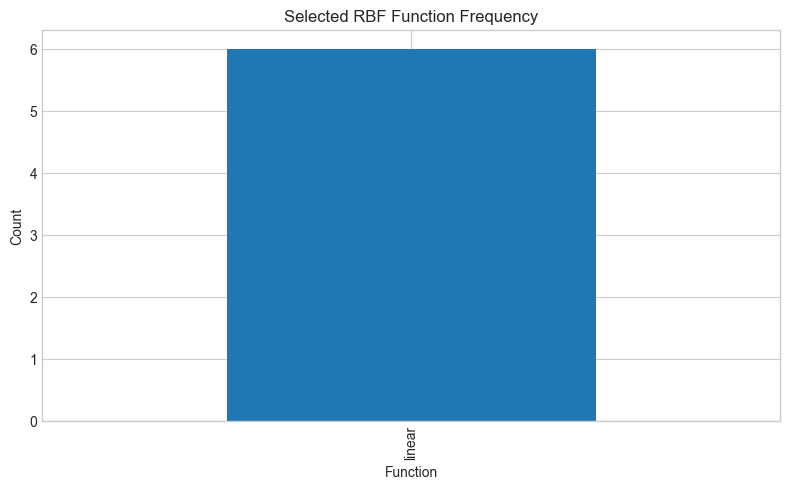


--- Phase 2: Final Reconstruction & MSE Validation ---


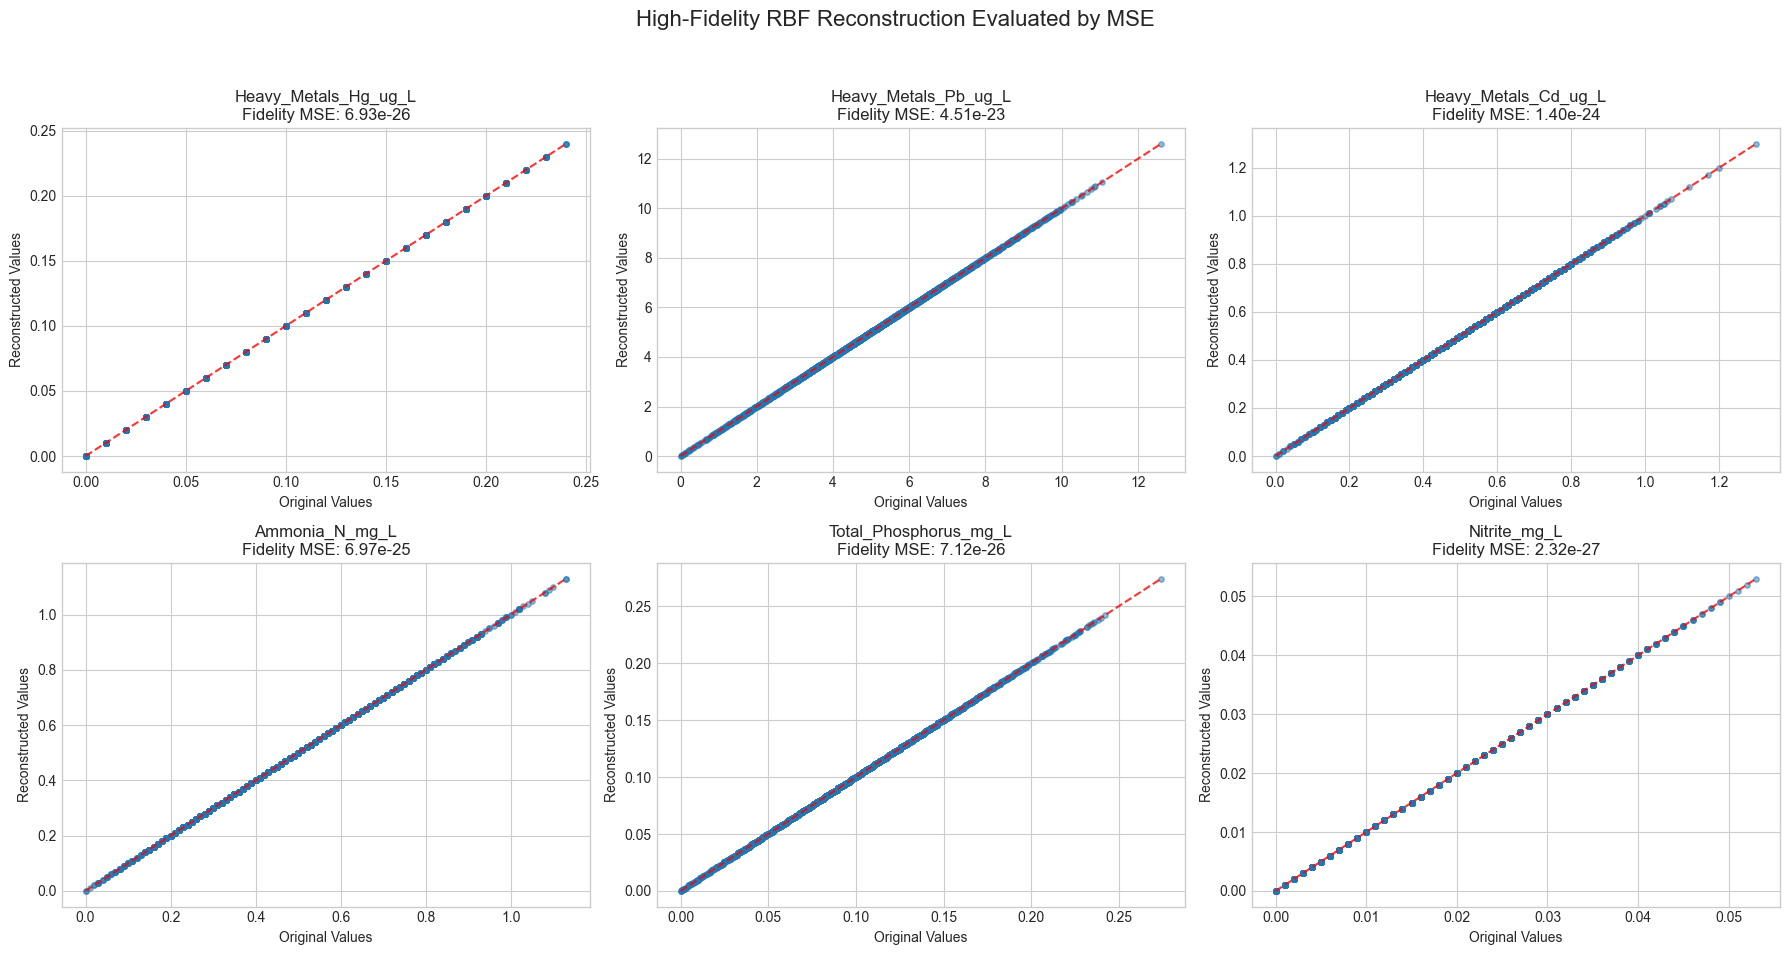


Process Complete. Dataset saved with optimized MSE and logged RBF functions.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 1. DATA LOADING & PREPARATION
try:
    df_raw = pd.read_csv('../data/china_water_pollution_data.csv')
    df_clean = df_raw.drop(columns=['Remarks'], errors='ignore')
    df_original = df_clean.copy()
    
    negative_value_cols = [
        'Heavy_Metals_Hg_ug_L', 'Heavy_Metals_Pb_ug_L', 'Heavy_Metals_Cd_ug_L',
        'Ammonia_N_mg_L', 'Total_Phosphorus_mg_L', 'Nitrite_mg_L'
    ]

    # Coordinate Scaling
    coords_scaler = MinMaxScaler()
    coords_raw = df_clean[['Longitude', 'Latitude']].values
    coords_scaled = coords_scaler.fit_transform(coords_raw)

    # 2. HYPER-PARAMETER OPTIMIZATION + LOGGING
    param_grid = {
        'function': ['multiquadric', 'inverse', 'gaussian', 'linear', 'thin_plate'],
        'smooth': [0.0, 0.01],
        'epsilon': [0.1, 0.5, 1.0]
    }

    best_params_map = {}
    rbf_performance = {col: [] for col in negative_value_cols}

    print("--- Phase 1: Minimizing Reconstruction MSE ---")

    for col in negative_value_cols:
        y_orig = df_original[col].values
        mask = (y_orig >= 0) & (~np.isnan(y_orig))
        X_v, y_v = coords_scaled[mask], y_orig[mask]

        target_scaler = StandardScaler()
        y_scaled = target_scaler.fit_transform(y_v.reshape(-1, 1)).flatten()

        best_mse = float('inf')
        best_cfg = {}

        for params in ParameterGrid(param_grid):
            try:
                rbf_test = Rbf(X_v[:, 0], X_v[:, 1], y_scaled, **params)

                y_fit_scaled = rbf_test(X_v[:, 0], X_v[:, 1])
                y_fit = target_scaler.inverse_transform(y_fit_scaled.reshape(-1, 1)).flatten()

                current_mse = mean_squared_error(y_v, y_fit)

                # Store performance
                rbf_performance[col].append({
                    'function': params['function'],
                    'smooth': params['smooth'],
                    'epsilon': params['epsilon'],
                    'mse': current_mse
                })

                if current_mse < best_mse:
                    best_mse = current_mse
                    best_cfg = params

            except:
                continue

        best_params_map[col] = best_cfg

        print(
            f"Target: {col:22} | "
            f"Best Function: {best_cfg.get('function')} | "
            f"Smooth: {best_cfg.get('smooth')} | "
            f"Epsilon: {best_cfg.get('epsilon')} | "
            f"MSE: {best_mse:.2e}"
        )

    # 3. SAVE SELECTED FUNCTIONS
    selection_log = []

    for col, cfg in best_params_map.items():
        selection_log.append({
            'target': col,
            'function': cfg.get('function'),
            'smooth': cfg.get('smooth'),
            'epsilon': cfg.get('epsilon')
        })

    selection_df = pd.DataFrame(selection_log)

    print("\nSelected RBF per target:")
    print(selection_df)

    selection_df.to_csv('../output/rbf_selected_functions.csv', index=False)

    # Plot frequency of selected functions
    func_counts = selection_df['function'].value_counts()

    plt.figure(figsize=(8, 5))
    func_counts.plot(kind='bar')
    plt.title('Selected RBF Function Frequency')
    plt.xlabel('Function')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # 4. FINAL SYNTHESIS & VALIDATION
    print("\n--- Phase 2: Final Reconstruction & MSE Validation ---")

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, col in enumerate(negative_value_cols):
        y_raw = df_original[col].values
        v_mask = (y_raw >= 0) & (~np.isnan(y_raw))

        t_scaler = StandardScaler()
        y_train_full_scaled = t_scaler.fit_transform(y_raw[v_mask].reshape(-1, 1)).flatten()

        cfg = best_params_map[col]
        final_rbf = Rbf(
            coords_scaled[v_mask, 0],
            coords_scaled[v_mask, 1],
            y_train_full_scaled,
            **cfg
        )

        full_pred_scaled = final_rbf(coords_scaled[:, 0], coords_scaled[:, 1])
        full_pred = np.maximum(
            t_scaler.inverse_transform(full_pred_scaled.reshape(-1, 1)).flatten(),
            0
        )

        df_clean[col] = np.where(v_mask, y_raw, full_pred)

        y_final_p = full_pred[v_mask]
        mse_val = mean_squared_error(y_raw[v_mask], y_final_p)

        ax = axes[idx]
        ax.scatter(y_raw[v_mask], y_final_p, alpha=0.5, s=15)
        limit = max(y_raw[v_mask].max(), y_final_p.max())
        ax.plot([0, limit], [0, limit], 'r--', alpha=0.8)

        ax.set_title(f"{col}\nFidelity MSE: {mse_val:.2e}")
        ax.set_xlabel('Original Values')
        ax.set_ylabel('Reconstructed Values')

    plt.suptitle('High-Fidelity RBF Reconstruction Evaluated by MSE', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # 5. SAVE FINAL DATASET
    df_clean.to_csv('../output/mse_healed_data.csv', index=False)

    print("\nProcess Complete. Dataset saved with optimized MSE and logged RBF functions.")

except Exception as e:
    print(f"Pipeline Error: {e}")